# Industrial Surface Defect Classification using Transfer Learning

## Objective

The aim of this assignment is to automatically classify surface defects in steel materials using real-world industrial image data and a transfer learning approach.

Surface defects such as cracks, scratches, inclusions, and pits commonly occur during manufacturing processes and can significantly affect product quality. Manual inspection of these defects is time-consuming, inconsistent, and difficult to scale.

In this assignment, we use a dataset containing steel surface images belonging to six different defect categories:
- Crazing  
- Inclusion  
- Patches  
- Pitted Surface  
- Rolled-in Scale  
- Scratches  

All defect types originate from the same manufacturing domain, and learning from all categories together allows the model to capture shared texture and structural patterns present across industrial surfaces.

The problem statement for this assignment is:

> **Given a steel surface image, predict the type of surface defect present in the image using a pretrained convolutional neural network.**

To solve this problem efficiently, we apply **transfer learning** by reusing a pretrained `MobileNetV2` model as a feature extractor and training only a lightweight classification head. This demonstrates how deep learning models can be adapted to real industrial use cases using limited data and computational resources.

## Business Value

In manufacturing industries such as steel, automotive, and heavy engineering, surface defects can directly impact product quality, safety, customer satisfaction, production cost, and rework rates.

Traditional inspection methods rely heavily on human inspectors, which introduces inconsistency in defect detection. Manual inspection also comes with high operational costs and scalability limitations.

By applying transfer learning, organisations can:
- Reuse pretrained visual intelligence instead of training models from scratch  
- Reduce development and training time  
- Achieve reliable defect detection even with smaller datasets  
- Deploy lightweight models suitable for real-time or edge-based inspection systems

## Dataset Description

This assignment uses the **NEU Surface Defect Dataset**, a real-world industrial dataset commonly used in manufacturing research and automated inspection systems.

### Dataset Characteristics:
- Images represent steel surface textures captured under industrial conditions  
- Each image belongs to one of six defect categories:
  - Crazing  
  - Inclusion  
  - Patches  
  - Pitted Surface  
  - Rolled-in Scale  
  - Scratches  
- Images are originally grayscale
- The dataset is reasonably balanced across classes  


#### Why this dataset?

- It represents a real industrial computer vision problem
- Defect patterns are texture-based, making it ideal for demonstrating transfer learning  
- The dataset size is moderate, encouraging the use of **partial transfer learning** rather than full model retraining  

## Flow Diagram

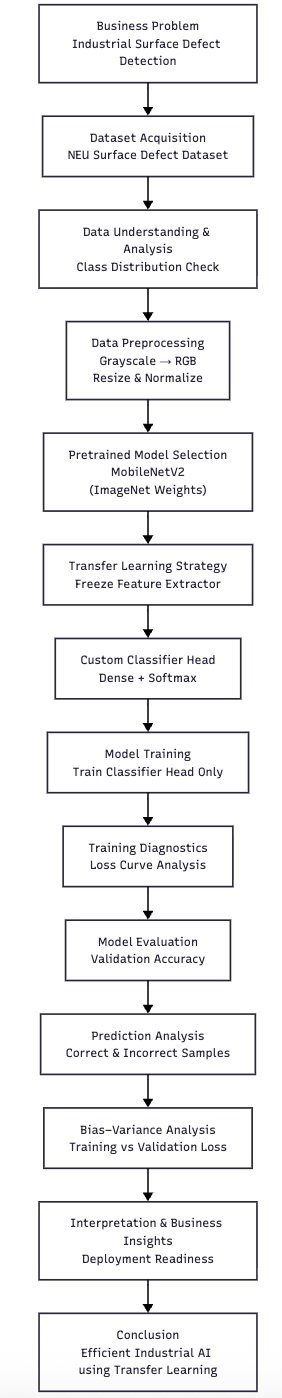

**Note:** You are free to choose any pre-trained model from the available ones. However, the architecture we suggest for this assignment is `MobileNetV2` with "ImageNet" weights.

The choice of libraries, frameworks, and backbones for this assignment are up to you. Before starting this assignment, please ensure that your environment meets the following requirements.


**Software Requirements**

- *Python version*: > Python3.11  
- *Execution environment*: Jupyter Notebook / JupyterLab / VS Code Notebook  
- *Operating system*: macOS, Linux, or Windows  


**Hardware Requirements**
- A GPU-powered training would be optimal, and would require installation of proper libraries and CUDA
- However, CPU-only execution might also be sufficient, and would work without CUDA

### Import Necessary libraries

In [ ]:
# Import Required Libraries

import os
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.preprocessing import image
from tensorflow.keras.utils import image_dataset_from_directory

from collections import Counter

## 1. Data Loading and Preparation

<font color=red>[10 marks]</font>

In any machine learning workflow, understanding and preparing the data correctly is a critical first step. Before building a deep learning model, it is important
to examine how the dataset is structured, how labels are assigned, and how images are preprocessed for training.

This section includes the following steps:
- Understanding the dataset organisation
- Verifying class labels and distributions
- Applying appropriate image transformations for transfer learning
- Development of train loader and validation loader

### 1.1 Dataset Understanding and Structure

<font color=red>[4 marks]</font>

The NEU Surface Defect Dataset consists of real-world grayscale images collected from steel manufacturing processes. Each image belongs to one of six surface defect categories.

The dataset is already split into **training** and **validation** sets, and images are organised into class-specific folders. This structure allows us to use PyTorch’s `ImageFolder` utility, which automatically assigns labels based on directory names.

The same directory-based structure is also compatible with TensorFlow, allowing the dataset to be loaded directly using `tf.keras.utils.image_dataset_from_directory`, which infers class labels from folder names in a similar manner.



Before proceeding, we load the dataset and verify:
- Number of images in training and validation sets
- Mapping between class names and numeric labels

#### **1.1.1** Load Images and Labels  <font color=red>[3 marks]</font>

Load the training and validation datasets and check the number of images and the number of categories present

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

rootFolder = "/content/drive/MyDrive/MLOps - Assignment 2/NEU-DET"

Mounted at /content/drive


In [ ]:
# Load training and validation images + labels

train_dir = os.path.join(rootFolder, "train/images")
val_dir = os.path.join(rootFolder, "validation/images")

# Dataset statistics
imgSize = (224, 224)
batchSize = 32

train_data = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=imgSize,
    batch_size=batchSize,
    label_mode='categorical'
)

valData = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=imgSize,
    batch_size=batchSize,
    label_mode='categorical'
)

class_names = train_data.class_names
print("Name of Classes:", class_names)
print("Number of classes:", len(class_names))


train_count = sum([len(files) for r, d, files in os.walk(train_dir)])
val_count = sum([len(files) for r, d, files in os.walk(val_dir)])
print("Training images:", train_count)
print("Validation images:", val_count)

Found 1440 files belonging to 6 classes.
Found 360 files belonging to 6 classes.
Name of Classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
Number of classes: 6
Training images: 1440
Validation images: 360


Here, the image loader automatically assigns numeric labels based on folder names. For example, all images inside the "crazing" folder receive the same label.

This approach reduces manual labeling effort and ensures consistency between directory structure and class definitions.

#### **1.1.2** Check and Visualise Class Distribution <font color=red>[1 mark]</font>

In [ ]:
# Dataset Class Distribution

def getClassCounts(directory):
    counts = {}
    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)
        if os.path.isdir(class_path):
            counts[class_name] = len(os.listdir(class_path))
    return counts

trainCounts = getClassCounts(train_dir)

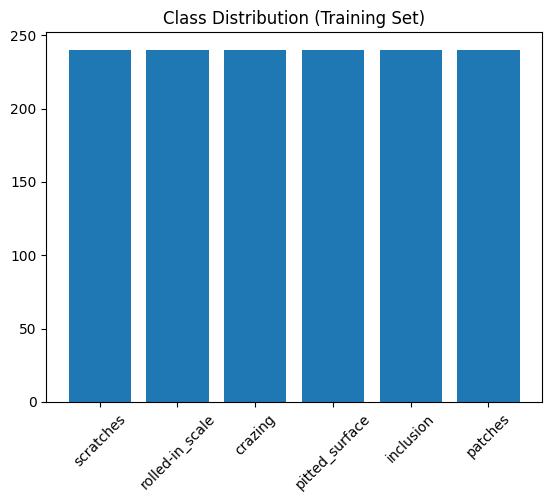

In [ ]:
# Visualise class distribution

plt.bar(trainCounts.keys(), trainCounts.values())
plt.xticks(rotation=45)
plt.title("Class Distribution (Training Set)")
plt.show()

### 1.2 Data Preprocessing and Transformations

<font color=red>[6 marks]</font>

Deep learning models pretrained on ImageNet expect images to be in a specific format. Although the NEU dataset images are grayscale, ImageNet-pretrained models require 3-channel RGB images with standardised dimensions and normalisation.

#### **1.2.1** Apply Image Transformations <font color=red>[4 marks]</font>

To ensure compatibility, we apply the following transformations:
- Convert grayscale images to RGB
- Resize images to a fixed resolution
- Normalize using ImageNet mean and standard deviation

These transformations are provided in [`transforms`](https://docs.pytorch.org/vision/0.24/transforms.html) from `torchvision`, while in TensorFlow the same preprocessing steps are applied using [`tf.image`](https://www.tensorflow.org/api_docs/python/tf/image) operations and `tf.keras.layers` within the input pipeline.

In PyTorch, normalization can be performed using `Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)`.

In TensorFlow, the same effect is achieved by explicitly standardising the images with the ImageNet statistics, i.e. subtracting `IMAGENET_MEAN` and dividing by `IMAGENET_STD` using `tf.image` operations or a custom `tf.keras.layers.Layer` within the preprocessing pipeline.

In [ ]:
# Image Transformations

def preprocess(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    if image.shape[-1] == 1:
        image = tf.image.grayscale_to_rgb(image)
    elif image.shape[-1] > 3:
        image = image[:, :, :3]
    return image, label

At this stage, the dataset is fully prepared for training a transfer learning model. Images are correctly formatted, normalized, and labeled, ensuring a smooth transition into model design and training.

#### **1.2.2** Create DataLoaders for both the training and validation datasets <font color=red>[2 marks]</font>


Deep learning models are trained on data in **batches** rather than loading the entire dataset into memory at once.

PyTorch provides the [`DataLoader`](https://docs.pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader) utility to batch the data, shuffle training samples and load data efficiently during training. For Tensorflow, you can use similar functionality provided by [`tf.data.Dataset` API](https://www.tensorflow.org/api_docs/python/tf/data/Dataset), which supports efficient batching, shuffling, prefetching, and parallel data loading within the input pipeline.

In [ ]:
# DataLoader Creation

train_data = train_data.shuffle(buffer_size=1000)
AUTOTUNE = tf.data.AUTOTUNE
train_data = train_data.prefetch(buffer_size=AUTOTUNE)
valData = valData.prefetch(buffer_size=AUTOTUNE)

Also decide on where to use shuffling - training or validation

## 2. Transferring Knowledge and Model Training

<font color=red>[25 marks]</font>

Training deep learning models from scratch requires large amounts of labeled data and computational resources. In many real-world scenarios, this is not feasible. Transfer learning addresses this challenge by reusing knowledge learned from a large source dataset (such as ImageNet) and adapting it to a new, related task.

### 2.1 Pretrained Model Selection

<font color=red>[15 marks]</font>

For this assignment, we will prefer **MobileNetV2**, a lightweight convolutional neural network pretrained on the ImageNet dataset. Though any pre-trained network will suit the task.

MobileNetV2 is computationally efficient and lightweight. It performs well on texture-based image classification tasks.

In this section:
- Select a suitable pretrained convolutional neural network
- Apply a partial transfer learning strategy
- Design a task-specific classifier for surface defect detection

#### **2.1.1** Load the Pre-Trained Model <font color=red>[5 marks]</font>

Load the pre-trained model of your choice. If you wish to use a different architecture from MobileNet, also explain the reason for your choice.

In [ ]:
# Load Pretrained Network

baseModel = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


The MobileNetV2 architecture consists of two main components:
- A **feature extractor** that learns visual representations
- A **classifier head** originally designed for ImageNet’s 1000 classes

#### **2.1.2** Freezing Strategy and Classifier Design <font color=red>[8 marks]</font>

Build the transfer learning model by loading and freezing the feature extractor layers.


Instead of retraining the entire network, we apply partial transfer learning. In this approach the pretrained feature extractor is frozen and only the classifier head is retrained for the new task. This strategy reduces the risk of overfitting and speeds up training.

In [ ]:
# Build Transfer Learning Model

for layer in baseModel.layers:
    layer.trainable = False
x = baseModel.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(len(class_names), activation='softmax')(x)

model = models.Model(inputs=baseModel.input, outputs=output)

#### **2.1.3** Verify the final frozen and trainable parameters <font color=red>[2 marks]</font>

In [ ]:
# Verify Freezing Strategy

trainableCount = sum([layer.trainable for layer in model.layers])
nonTrainableCount = len(model.layers) - trainableCount

print("Trainable layers:", trainableCount)
print("Frozen layers:", nonTrainableCount)

Trainable layers: 4
Frozen layers: 154


### 2.2 Model Training

<font color=red>[10 marks]</font>

After designing the transfer learning model, the next step is to train it on the prepared dataset.

We only train the classifier head, while the pretrained feature extractor remains frozen. This allows the model to adapt quickly to the surface defect classification task.

In this section, we:
- Configure the training setup
- Train the model for a small number of epochs
- Track training loss to verify learning progress

#### **2.2.1** Training Configuration <font color=red>[3 marks]</font>

Before starting the training loop, we define:
- The computation device: CPU or GPU
- The loss function: Use a suitable loss function (one of the cross-entropy losses would work fine here)
- The optimizer: preferably [Adam](https://arxiv.org/abs/1412.6980) from [Tensorflow](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/Adam) or [Pytorch](https://docs.pytorch.org/docs/stable/generated/torch.optim.Adam.html)

These components control how the model learns from data and how its parameters are updated during training.

In [ ]:
# Training Configuration

model.compile(
    optimizer=Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available: 0


#### **2.2.2** Model Training Loop <font color=red>[5 marks]</font>

Perform the training and track the training loss across epochs to verify whether the model is learning effectively.

The training loop iterates over the dataset multiple times (epochs). For each batch of images, the model:
- Performs a forward pass
- Computes the loss
- Updates the trainable parameters using backpropagation

In [ ]:
# Model Training

history = model.fit(
    train_data,
    validation_data=valData,
    epochs=10
)

Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 598s 5s/step - accuracy: 0.5472 - loss: 1.1263 - val_accuracy: 0.6750 - val_loss: 0.7143
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 75s 2s/step - accuracy: 0.7778 - loss: 0.5860 - val_accuracy: 0.8722 - val_loss: 0.4513
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 75s 2s/step - accuracy: 0.8111 - loss: 0.4816 - val_accuracy: 0.8472 - val_loss: 0.4306
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 75s 2s/step - accuracy: 0.8410 - loss: 0.4168 - val_accuracy: 0.9194 - val_loss: 0.3390
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.8542 - loss: 0.3784 - val_accuracy: 0.8972 - val_loss: 0.3213
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - accuracy: 0.8583 - loss: 0.3587 - val_accuracy: 0.8583 - val_loss: 0.3328
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - accuracy: 0.8792 - loss: 0.3183 - val_accuracy: 0.8722 - val_loss: 0.3027
Epoch 8/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.8764 - loss: 0.3010 - val_accuracy: 0.8417 - val_loss

#### **2.2.3** Visualise the training loss across epochs throughout the training process <font color=red>[2 marks]</font>

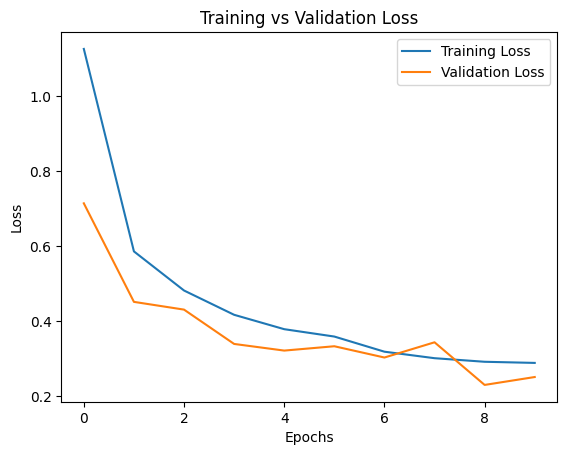

In [ ]:
# Training Loss Visualisation

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

## 3. Evaluation and Final Predictions

<font color=red>[10 marks]</font>

After training the model, it is essential to evaluate how well it performs on unseen data. Evaluation helps us understand whether the model has learned generalisable patterns or has simply memorised the training data.

In this section, we:
- Measure model performance using validation accuracy
- Analyse predictions at the individual data-point level
- Examine model behavior using diagnostic plots

### 3.1 Evaluation Metrics and Bias-Variance Tradeoff

<font color=red>[6 marks]</font>

#### **3.1.1** Calculate Appropriate Evaluation Metrics to Assess Model Performance <font color=red>[3 marks]</font>

For this multi-class classification problem, we use **accuracy** as the primary evaluation metric.

Accuracy measures the proportion of validation samples that are correctly classified by the model. Since the dataset is reasonably balanced across classes, accuracy provides a reliable indication of overall performance.

In [ ]:
# Model Evaluation

loss, accuracy = model.evaluate(valData)

print("Validation Loss:", round(loss,2))
print("Validation Accuracy:", round(accuracy*100,2))

12/12 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.9278 - loss: 0.2507
Validation Loss: 0.25
Validation Accuracy: 92.78


#### **3.1.2** Dataset Diagnostics <font color=red>[3 marks]</font>

Beyond accuracy, diagnostic analysis helps assess whether the model is underfitting, overfitting, or generalising well

Analyse this using training and validation loss trends, along with dataset class distribution.

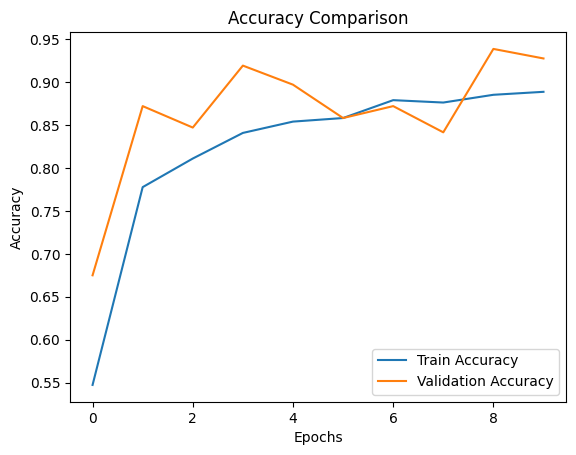

In [ ]:
# Training and Validation Loss Analysis
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison")
plt.legend()
plt.show()

### 3.2 Prediction Analysis

<font color=red>[4 marks]</font>

Overall accuracy provides a summary metric, but it does not reveal how individual predictions contribute to that score.

To better understand model behavior, we examine predictions at the individual image level, highlighting both correct and incorrect classifications.

#### **3.2.1** Visualise the prediction on a few sample images from validation set <font color=red>[4 marks]</font>

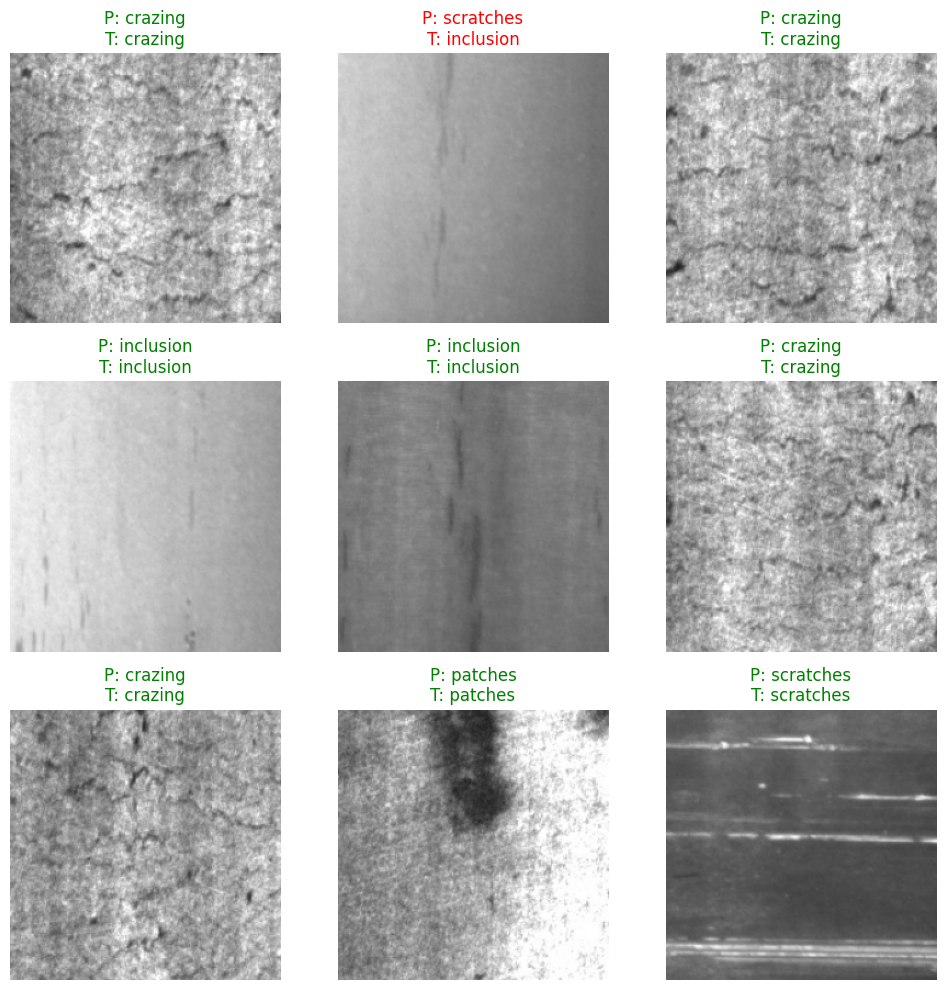

In [ ]:
# Visualisation of Validation Predictions

plt.figure(figsize=(10, 10))
for images, labels in valData.take(1):
    images = images.numpy()
    labels = labels.numpy()
    preds = model.predict(images, verbose=0)
    for i in range(9):
        plt.subplot(3, 3, i+1)
        img = images[i]
        if img.max() <= 1.0:
            img = img * 255.0
        img = img.astype("uint8")
        plt.imshow(img)
        pred = class_names[np.argmax(preds[i])]
        true = class_names[np.argmax(labels[i])]
        color = "green" if pred == true else "red"
        plt.title(f"P: {pred}\nT: {true}", color=color)
        plt.axis("off")
plt.tight_layout()
plt.show()

## 4 Conclusion

<font color =red> [5 marks] </font>

### 4.1 Conclusion and insights

<font color =red> [5 marks] </font>

#### **4.1.1** Conclude with the insights drawn and final outcomes and results. Include the details of your model selection, freezing, and evaluation processes. <font color =red> [5 marks] </font>


*Answer below:*

The model, MobileNetV2, is a lightweight and computationally efficient architecture which is suitable for real-time industrial applications.
Since it is pretrained on ImageNet, it can capture low-level and mid-level visual features and patterns for detection of defects. The design of the model reduces computation without compromising accuracy.

The dataset has 1440 training and 360 validation images across 6 classes. We can assume that the dataset is reasonably balanced. Some key pre-processing steps done are resizing of images to 224 x 224, normalisation of pixel values and conversion of images from grayscale to RGB.

A transfer learning approach was used where the pretrained MobileNetV2 feature extractor layer was frozen and a custom classification head was trained on top of it. To enhance the model training process, a global average pooling layer and dropout layer of 0.5 was added. This helped in reducing training time while minimising the chance of overfitting.

From the training logs, we see that the training accuracy improved from 54% to 89% with validation accuracy peaking at 93.89% in epoch 9. From the graphs, we see that the training loss decreased steadily while the validation loss initially decreased and then fluctuated slightly. This suggests that the model was able to learn the patterns quickly and that resulted in mild overfitting after epoch 9, hence implying that early stopping could improve generalisation of the model.

Overall, we see that the final validation accuracy is 92.78% with a validation loss of 0.25. This indicates that
1) the dataset is quite balanced
2) the model is able to generalise well to new and unseen data
3) the model is not biased to any class present in the dataset.
4) the validation loss decreased overall with very minor fluctuations.

From the image outputs, we see that majority of the predictions were correct (based on the green labels). The misclassification could be due to similar texture patterns and subtle visual differences between the categories. This suggests that the model is able to capture dominant visual patterns well enough.